<a href="https://colab.research.google.com/github/JoyNgaru/ai_engineering/blob/main/FFT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

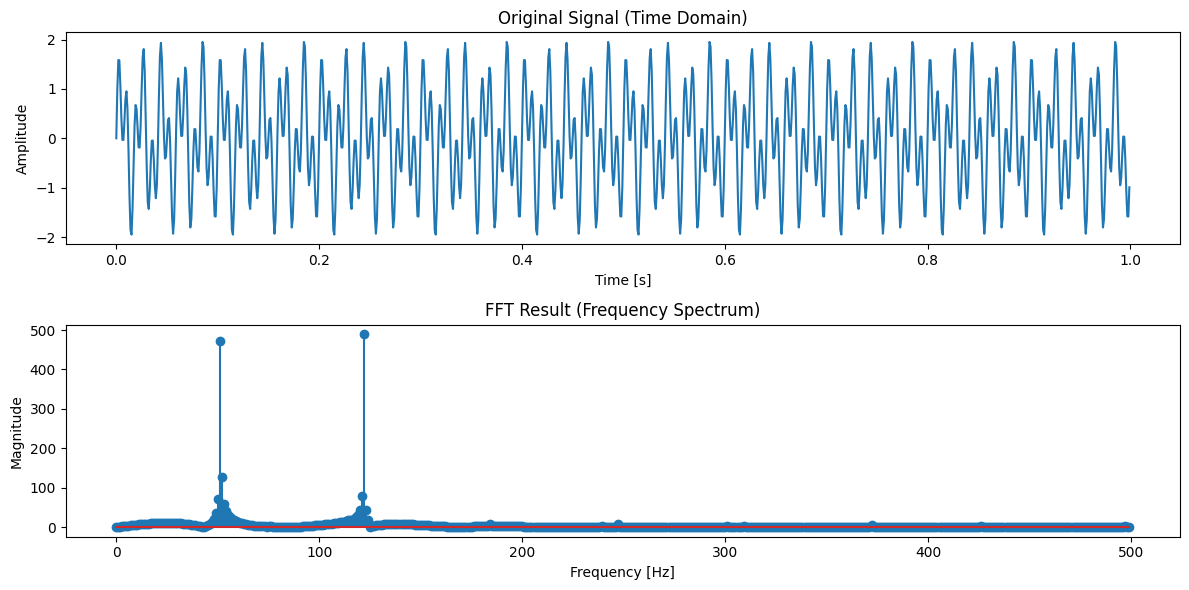

In [3]:
"""
fft_last_firstname.py
Implementation of Fast Fourier Transform (FFT) from scratch
with a simple sine wave example.
"""

import numpy as np
import matplotlib.pyplot as plt

def fft(x):
    """
    Recursive Cooley-Tukey FFT.
    Pads input to next power of 2 if needed.
    """
    N = len(x)
    if N <= 1:
        return x
    if N % 2 != 0:  # pad if not power of 2
        x = np.append(x, 0)
        N = len(x)
    even = fft(x[0::2])
    odd = fft(x[1::2])
    terms = [np.exp(-2j * np.pi * k / N) * odd[k] for k in range(N // 2)]
    return [even[k] + terms[k] for k in range(N // 2)] + \
           [even[k] - terms[k] for k in range(N // 2)]

# --- Test Signal ---
Fs = 1000  # Sampling frequency
T = 1/Fs   # Sampling interval
t = np.arange(0,1,T)  # Time vector

# Signal: sine wave at 50Hz + sine wave at 120Hz
signal = np.sin(2*np.pi*50*t) + np.sin(2*np.pi*120*t)

# Apply FFT
N = len(signal)
fft_result = fft(signal)
fft_result = np.array(fft_result)

# Frequency axis
freqs = np.fft.fftfreq(len(fft_result), T)

# --- Plot ---
plt.figure(figsize=(12,6))

# Time domain
plt.subplot(2,1,1)
plt.plot(t, signal)
plt.title("Original Signal (Time Domain)")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")

# Frequency domain
plt.subplot(2,1,2)
plt.stem(freqs[:len(freqs)//2], np.abs(fft_result)[:len(freqs)//2])
plt.title("FFT Result (Frequency Spectrum)")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Magnitude")


plt.tight_layout()
plt.show()
